# Collagen ECM features — walkthrough

This notebook takes the collagen images in your **`Data`** folder, cleans them up,
measures a bunch of things about the collagen, and stacks the results into one
table. Then a quick look at which measurements are redundant.

**Before running:** make sure `feature_extraction.py` is in this same `ECM` folder,
and your collagen `.tiff` files are inside the `Data` folder. It works whether you
have 1 file or 4 — start with what you have.

In [7]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skimage as ski

import feature_extraction as fe   # the module with all the measuring functions

## 1. Find and load the collagen images
This grabs every file in the `Data` folder whose name contains "Collagen".
It doesn't matter if they're named `In113_113In_Collagen (1).tiff` etc. — it finds
them automatically. An image is just a grid of numbers = how much collagen at each spot.

Found 4 collagen file(s):
   Data/In113_113In_Collagen (1).tiff
   Data/In113_113In_Collagen copy 2.tiff
   Data/In113_113In_Collagen copy 3.tiff
   Data/In113_113In_Collagen copy.tiff


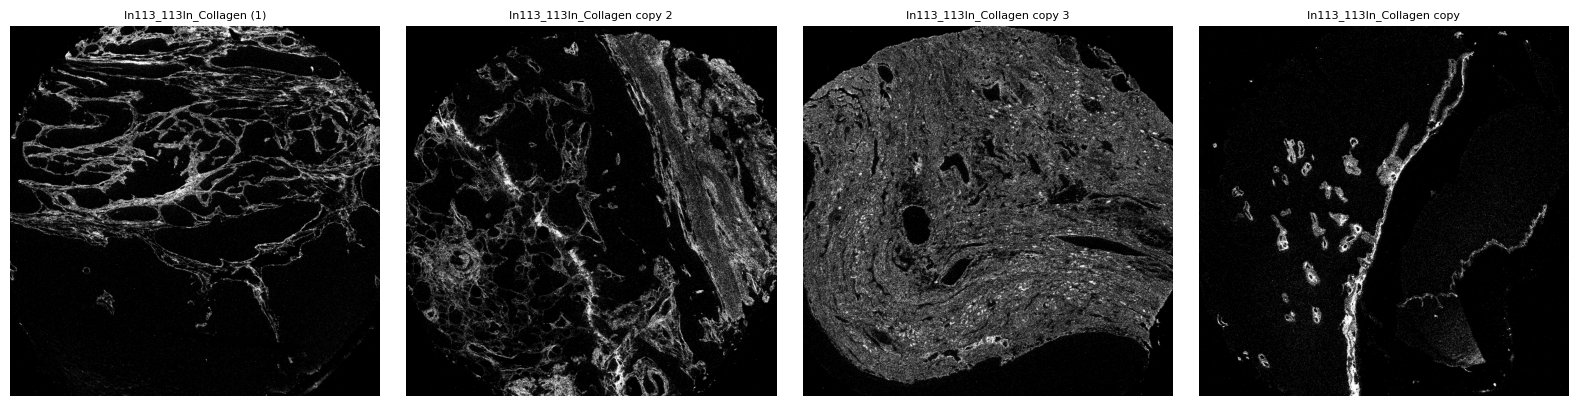

In [8]:
files = sorted(glob.glob("Data/*Collagen*.tif*"))
print(f"Found {len(files)} collagen file(s):")
for f in files:
    print("  ", f)

raw_images = [ski.io.imread(f) for f in files]
names = [f.split("/")[-1].replace(".tiff", "").replace(".tif", "") for f in files]

n = len(raw_images)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1:
    axes = [axes]
for ax, img, name in zip(axes, raw_images, names):
    ax.imshow(img, cmap="gray", vmax=np.percentile(img, 99))
    ax.set_title(name, fontsize=8); ax.axis("off")
plt.tight_layout()

## 2. Preprocess: the arcsinh transform
The raw numbers are lopsided (lots of zeros, a few huge values). `arcsinh` squishes
the scale so big values come closer to small ones. This is the step that was
missing before. Here's the before/after on the first image.

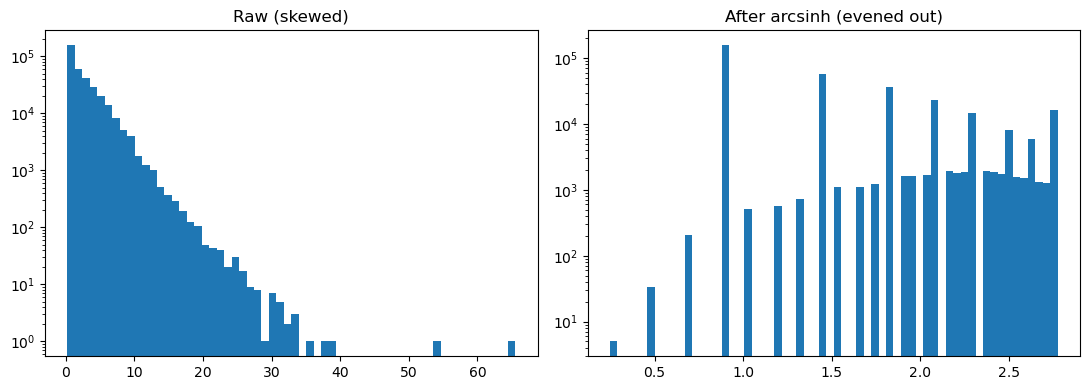

In [9]:
raw = raw_images[0]
proc = fe.preprocess(raw)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(raw[raw > 0].ravel(), bins=60); ax[0].set_yscale("log")
ax[0].set_title("Raw (skewed)")
ax[1].hist(proc[proc > 0].ravel(), bins=60); ax[1].set_yscale("log")
ax[1].set_title("After arcsinh (evened out)")
plt.tight_layout()

## 3. Measure everything -> one row of numbers per image
`extract_features` runs all the steps (coverage, brightness, Gabor texture, fibers,
alignment) and returns a row. We stack the rows into a table: one row per image,
one column per measurement.

In [10]:
rows = []
for img, name in zip(raw_images, names):
    row = {"name": name}
    row.update(fe.extract_features(img))
    rows.append(row)

features = pd.DataFrame(rows).set_index("name")
print("Table shape:", features.shape, "(rows = images, columns = measurements)")
features

Table shape: (4, 35) (rows = images, columns = measurements)


,area_fraction,collagen_mean,collagen_median,collagen_sd,porosity,gabor_t0_f0.04_mean,gabor_t0_f0.04_var,gabor_t0_f0.08_mean,gabor_t0_f0.08_var,gabor_t0_f0.12_mean,...,gabor_t135_f0.08_mean,gabor_t135_f0.08_var,gabor_t135_f0.12_mean,gabor_t135_f0.12_var,meij_fiber_area,meij_skeleton_len,sato_fiber_area,sato_skeleton_len,alignment_coherence,dominant_orientation_rad
name,,,,,,,,,,,,,,,,,,,,,
In113_113In_Collagen (1),24.027708,1.469784,1.443635,0.635106,75.972292,0.166058,0.024712,0.078399,0.004064,0.051149,...,0.095566,0.006421,0.060648,0.002223,0.188505,52943,0.188244,57049,0.141384,-0.029000
In113_113In_Collagen copy 2,29.934236,1.352955,1.443635,0.523397,70.065764,0.161452,0.023821,0.090502,0.005682,0.062253,...,0.094976,0.006500,0.065745,0.002515,0.258903,90597,0.273300,116525,0.064437,-0.184042
In113_113In_Collagen copy 3,60.730000,1.509527,1.443635,0.548974,39.270000,0.126848,0.008630,0.086477,0.003189,0.068756,...,0.089011,0.003483,0.070098,0.001833,0.402404,176810,0.398680,238983,0.049349,0.002766
In113_113In_Collagen copy,9.043194,1.185431,0.881374,0.449485,90.956806,0.184435,0.054399,0.094718,0.013104,0.057777,...,0.081444,0.009091,0.047975,0.002592,0.070988,26698,0.083209,37663,0.060043,0.021740


## 4. Save the table
This drops a CSV into your `Features` folder — that's your deliverable.

In [11]:
features.to_csv("Features/collagen_features.csv")
print("saved Features/collagen_features.csv")

saved Features/collagen_features.csv


## 5. Which measurements are redundant?
Many filters secretly measure the same thing. We **z-score** first (put every
column on the same footing) then look at a correlation heatmap: red pairs move
together, so we'd only keep one of them.

> Note: this only becomes meaningful once you have several cores in the table.
> With 1–2 images it's just showing the machinery works.

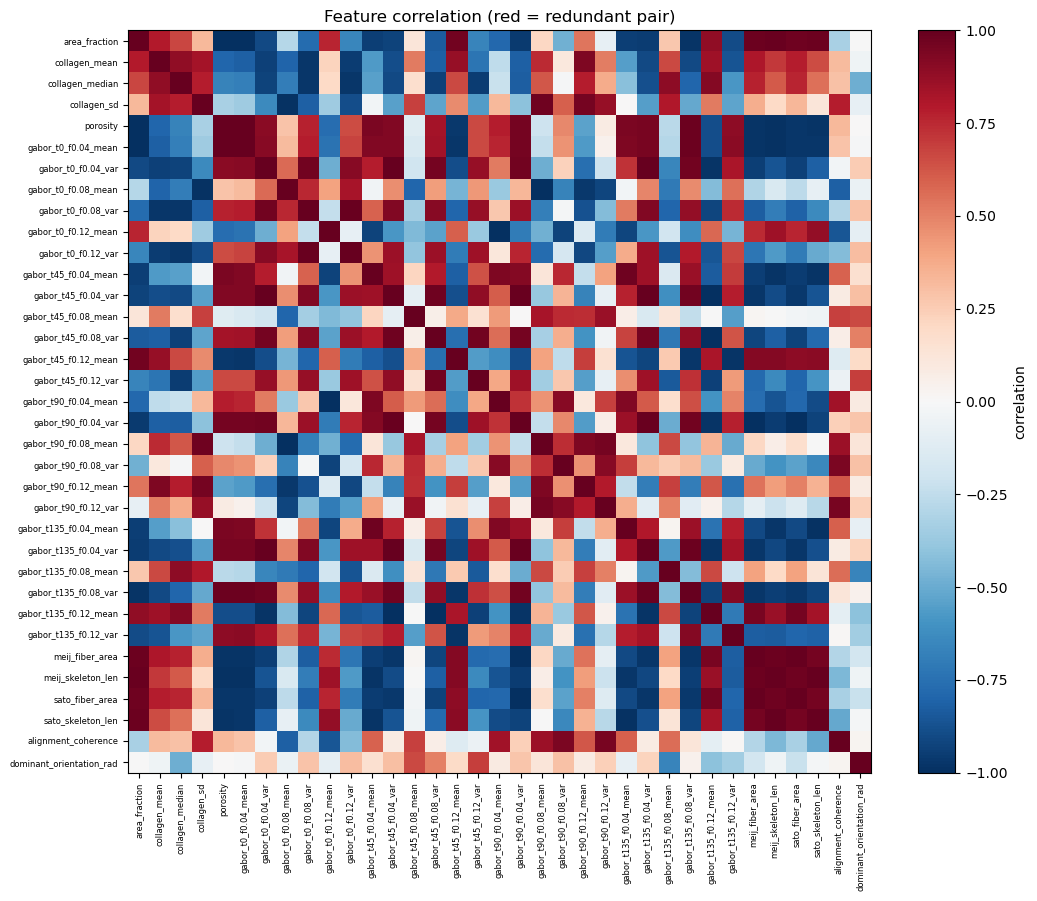

In [12]:
if len(features) >= 3:
    zscored = (features - features.mean()) / (features.std() + 1e-8)
    corr = zscored.corr()
    fig, ax = plt.subplots(figsize=(11, 9))
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=6)
    ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=6)
    fig.colorbar(im, label="correlation")
    ax.set_title("Feature correlation (red = redundant pair)")
    plt.tight_layout()
else:
    print(f"Only {len(features)} image(s) so far — add more cores to Data/ for a "
          "meaningful correlation heatmap. The table above is still your deliverable.")